In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv(r"C:\Users\asmit\Desktop\Delhi House Price project\Delhi_v2.csv")

In [4]:
data.head()

,Unnamed: 0,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,Balcony,Status,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft
0,0,5600000.0,"Noida Extension, Noida, Delhi NCR",1350.0,28.608850,77.460560,3.0,3.0,NaN,Under Construction,New Property,NaN,NaN,2.0,NaN,Flat,\n\n\n Welcome ...,4148.148148
1,1,8800000.0,"Sector 79, Gurgaon, Delhi NCR",1490.0,28.374236,76.952416,3.0,3.0,NaN,Ready to Move,New Property,NaN,Semi-Furnished,2.0,NaN,Flat,\n\n\n Mapsko M...,5906.040268
2,2,16500000.0,"Vaishali, Ghaziabad, Delhi NCR",2385.0,28.645769,77.385110,4.0,5.0,NaN,Ready to Move,New Property,1.0,Unfurnished,NaN,NaN,Flat,\n\n\n This pro...,6918.238994
3,3,3810000.0,"Link Road, F Block, Sector 50, Noida, Uttar Pr...",1050.0,28.566914,77.436434,2.0,2.0,3.0,NaN,New Property,1.0,Unfurnished,2.0,near Gaur Mulberry Mansion,Flat,\n\n\n AIG Roya...,3628.571429
4,4,6200000.0,"Jaypee Pavilion Court Sector 128, Noida, Secto...",1350.0,28.520732,77.356491,2.0,2.0,3.0,Ready to Move,Resale,1.0,NaN,3.0,NaN,Flat,\n\n\n The prop...,4592.592593


# DATA CLEANING

In [5]:
data=data.drop(columns=["Unnamed: 0","Price_sqft","desc","Landmarks"])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7738 entries, 0 to 7737
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             7738 non-null   float64
 1   Address           7738 non-null   object 
 2   area              7738 non-null   float64
 3   latitude          7738 non-null   float64
 4   longitude         7738 non-null   float64
 5   Bedrooms          7738 non-null   float64
 6   Bathrooms         7738 non-null   float64
 7   Balcony           5166 non-null   float64
 8   Status            7164 non-null   object 
 9   neworold          7738 non-null   object 
 10  parking           2612 non-null   float64
 11  Furnished_status  4124 non-null   object 
 12  Lift              1733 non-null   float64
 13  type_of_building  7738 non-null   object 
dtypes: float64(9), object(5)
memory usage: 846.5+ KB


In [7]:
missing_value=data.isnull().sum()

In [8]:
missing_percentage=(missing_value/len(data))*100

In [9]:
missing_percentage.sort_values(ascending=False)

Lift                77.604032
parking             66.244508
Furnished_status    46.704575
Balcony             33.238563
Status               7.417937
price                0.000000
Address              0.000000
area                 0.000000
latitude             0.000000
longitude            0.000000
Bedrooms             0.000000
Bathrooms            0.000000
neworold             0.000000
type_of_building     0.000000
dtype: float64

In [10]:
# there is 77% of data in the lift column is null we cant fill this with 0 or anything because in delhi ncr this is 
#not possible this much of flats with no list 
# so we have to drop the column now,this is th best idea for this situation

In [11]:
data=data.drop(columns=["Lift"])

In [12]:
#IN parking column there is 66% null values .....after seeing the data carefully there is no 0 in the dataset of parking column
#so we are going to fill the null values of parking column with 0


In [13]:
data["parking"]=data["parking"].fillna(0)

In [14]:
data["parking"].isnull().sum()

np.int64(0)

In [15]:
#now we are going to work on missing values of column balcony
#the strategy is in this column it is possible most oif the flats has 0 balcony but in the datset there is no 0 balcony
# so i decided to fill the null values with 0


In [16]:
data["Balcony"]=data["Balcony"].fillna(0)

In [17]:
data["Balcony"].isnull().sum()

np.int64(0)

In [18]:
#we are doing mode operation on status column 

In [19]:
data["Status"].mode()

0    Ready to Move
Name: Status, dtype: object

In [20]:
data["Status"].mode(0)

0    Ready to Move
Name: Status, dtype: object

In [21]:
mode_value=data["Status"].mode()[0]

In [22]:
data["Status"]=data["Status"].fillna(mode_value)

In [23]:
data["Status"].isnull().sum()

np.int64(0)

In [24]:
#now we are going to work on column furnished_status
#for this column our strategy is to replace the NaN value with "unknown" 


In [25]:
data["Furnished_status"]=data["Furnished_status"].fillna("unknown")

In [26]:
data["Furnished_status"].isnull().sum()

np.int64(0)

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7738 entries, 0 to 7737
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             7738 non-null   float64
 1   Address           7738 non-null   object 
 2   area              7738 non-null   float64
 3   latitude          7738 non-null   float64
 4   longitude         7738 non-null   float64
 5   Bedrooms          7738 non-null   float64
 6   Bathrooms         7738 non-null   float64
 7   Balcony           7738 non-null   float64
 8   Status            7738 non-null   object 
 9   neworold          7738 non-null   object 
 10  parking           7738 non-null   float64
 11  Furnished_status  7738 non-null   object 
 12  type_of_building  7738 non-null   object 
dtypes: float64(8), object(5)
memory usage: 786.0+ KB


# EDA

In [28]:
data["price"].max()

85000000.0

In [29]:
data["price"].min()

1700000.0

In [30]:
data["price"].mean()


np.float64(8320634.530886534)

In [31]:
data["price"].median()

6000000.0

In [32]:
data["price"].std()

7223197.499024976

In [33]:
data["price"].skew()

np.float64(3.5005877646358132)

In [34]:
# we are going to convert the price into log function due to reduce the large gaps between them

In [35]:
data["log_price"]=np.log(data["price"])

In [36]:
print("original skew:",data["price"].skew())
print("Log_skew:",data["log_price"].skew())

original skew: 3.5005877646358132
Log_skew: 0.7906013331830687


In [37]:
data.columns

Index(['price', 'Address', 'area', 'latitude', 'longitude', 'Bedrooms',
       'Bathrooms', 'Balcony', 'Status', 'neworold', 'parking',
       'Furnished_status', 'type_of_building', 'log_price'],
      dtype='object')

In [38]:
data["latitude"].min()

28.24002265930176

In [39]:
data["latitude"].max()

28.7997475777292

In [40]:
data["longitude"].min()

76.8841009

In [41]:
data["longitude"].max()

77.688028

In [42]:
data.isnull().sum()

price               0
Address             0
area                0
latitude            0
longitude           0
Bedrooms            0
Bathrooms           0
Balcony             0
Status              0
neworold            0
parking             0
Furnished_status    0
type_of_building    0
log_price           0
dtype: int64

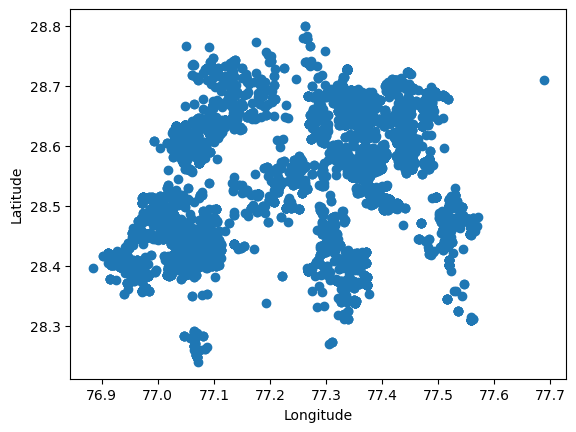

In [43]:
# we are using ploting here for checking the density of house within the city according to latitude and logitude

plt.scatter(data["longitude"],data["latitude"])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

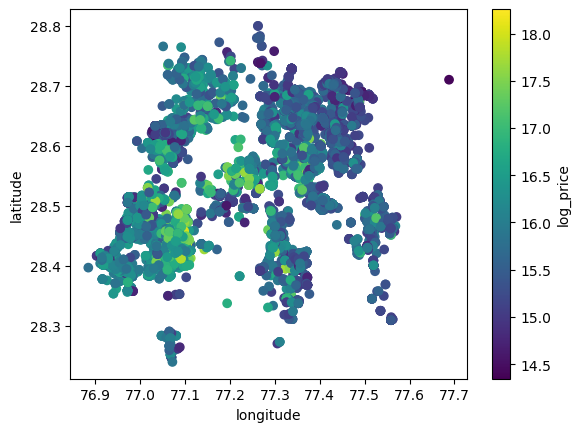

In [44]:
# we are using scatter plot latitude vs longitude log_price with color variation to check price of 
# house according to location

plt.scatter(
    data["longitude"],
    data["latitude"],
    c=data["log_price"],
    cmap="viridis"
)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar(label="log_price")
plt.show()

In [45]:
data["log_price"].mean()

np.float64(15.711576262797362)

In [86]:
label=data["log_price"]
feature=data.drop(columns=["log_price"])

In [46]:
filtered=data[
    data["latitude"].between(28.4,28.6) &
    data["longitude"].between(77.0,77.4)

    ]
filtered["log_price"].mean()

np.float64(16.051745777437816)

In [47]:
# now we are going to separate longitude and latitude for clustering
x_geo=data[["latitude","longitude"]]

In [48]:
x_geo.shape

(7738, 2)

In [49]:
# we are doing scalling because we further use kmean which is basically a distance dependent algorith
# in our dataset of latitude and logitude many range values are there we need to every values small and big on the same plane

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled=scaler.fit_transform(x_geo)

In [50]:
scaled[:5]

array([[ 0.52840585,  1.0359339 ],
       [-1.65582002, -1.77779229],
       [ 0.87211631,  0.61814726],
       [ 0.13798785,  0.90234184],
       [-0.29195978,  0.45967628]])

In [51]:
# now i am starts clestering of latitude and longitude according to the price

from sklearn.cluster import KMeans

kmeans=KMeans(n_clusters=4,random_state=42)
kmeans.fit(scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [52]:
data["location_cluster"]=kmeans.labels_

In [53]:
data["location_cluster"].value_counts()

location_cluster
2    3479
1    1847
3    1424
0     988
Name: count, dtype: int64

In [54]:
data.groupby("location_cluster")["log_price"].mean()

location_cluster
0    15.937442
1    16.130885
2    15.479520
3    15.577943
Name: log_price, dtype: float64

In [55]:
# in above opertion we found in group 1 log_price mean is 16.1 it is much high then all so its mean premium houses are in 
# cluster 1

In [56]:
# we are going to drop latitude and longitude now because we have there simpler version that is loaction_cluster

data=data.drop(columns=["latitude","longitude"])

In [57]:
data.columns

Index(['price', 'Address', 'area', 'Bedrooms', 'Bathrooms', 'Balcony',
       'Status', 'neworold', 'parking', 'Furnished_status', 'type_of_building',
       'log_price', 'location_cluster'],
      dtype='object')

In [ ]:
num_attibutes=["area","Bedrooms","Bathrooms","Balcony","parking","log_price"]

# Categorical Encoding phase

In [58]:
# i am checking the ordinal of the categorical values
data["Status"].unique()
# data["Furnished_status"].unique()
# data["type_of_building"].unique()
# data["neworold"].unique()
# data["location_cluster"].unique()

array(['Under Construction', 'Ready to Move'], dtype=object)

In [59]:
 data["Furnished_status"].unique()

array(['unknown', 'Semi-Furnished', 'Unfurnished', 'Furnished'],
      dtype=object)

In [60]:
data["type_of_building"].unique()

array(['Flat', 'Individual House'], dtype=object)

In [61]:
data["neworold"].unique()

array(['New Property', 'Resale'], dtype=object)

In [62]:
x=data.drop(columns=["price","log_price"])

In [63]:
y=data["log_price"]

In [64]:
data.columns

Index(['price', 'Address', 'area', 'Bedrooms', 'Bathrooms', 'Balcony',
       'Status', 'neworold', 'parking', 'Furnished_status', 'type_of_building',
       'log_price', 'location_cluster'],
      dtype='object')

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [67]:
print(x_train.shape)

(6190, 11)


In [68]:
print(x_test.shape)

(1548, 11)


In [69]:
x_train=x_train.drop(columns=["Address"])
x_test=x_test.drop(columns=["Address"])

In [70]:
categorical_cols = [
    "Status",
    "Furnished_status",
    "type_of_building",
    "neworold",
    "location_cluster"
]

In [71]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(drop="first", handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, categorical_cols)
    ],
    remainder="passthrough"
)

In [72]:
x_train_encoded = preprocessor.fit_transform(x_train)
x_test_encoded = preprocessor.transform(x_test)

In [73]:
x_train_encoded.shape

(6190, 14)

In [74]:
from sklearn.linear_model import LinearRegression

In [75]:
model=LinearRegression()

In [76]:
model.fit(x_train_encoded,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
y_pred=model.predict(x_test_encoded)

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.23449830089573295
RMSE: 0.3076996137017179
R2: 0.7474474392463148


In [79]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(x_train_encoded, y_train)

y_pred_dt = model_dt.predict(x_test_encoded)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2:", r2_dt)

Decision Tree Results
MAE: 0.22960975155996774
RMSE: 0.30348597687144796
R2: 0.7543169859810013


In [80]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(x_train_encoded, y_train)

y_pred_rf = model_rf.predict(x_test_encoded)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Results
MAE: 0.19025436448812102
RMSE: 0.2481544703227935
R2: 0.8357361186046739


In [81]:
print("Train R2:", model_rf.score(x_train_encoded, y_train))
print("Test R2:", model_rf.score(x_test_encoded, y_test))

Train R2: 0.9668650279393699
Test R2: 0.835736118604674


In [82]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_rf,
    x_train_encoded,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV R2 Mean:", cv_scores.mean())

CV R2 Mean: 0.8337064625033873


In [83]:
# now we are converting log_price into original price

# Predict on test set
y_pred_log = model_rf.predict(x_test_encoded)

# Convert back to original price
y_pred_actual = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)

y_pred_actual[:5]

array([ 4121194.77233909, 14187300.49482622,  6626069.55603789,
        6731333.67859332,  9188002.92215653])

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("Real Price MAE:", mae_actual)
print("Real Price RMSE:", rmse_actual)

Real Price MAE: 1571962.5216021563
Real Price RMSE: 2788514.8793059574


In [85]:
data.columns

Index(['price', 'Address', 'area', 'Bedrooms', 'Bathrooms', 'Balcony',
       'Status', 'neworold', 'parking', 'Furnished_status', 'type_of_building',
       'log_price', 'location_cluster'],
      dtype='object')

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load original CSV
data = pd.read_csv("Delhi_v2.csv")

# Latitude & Longitude lo
geo = data[["latitude", "longitude"]]

# Scale karo
scaler = StandardScaler()
geo_scaled = scaler.fit_transform(geo)

# Same clusters count use karo jo training me use kiya tha
kmeans = KMeans(n_clusters=4, random_state=42)

data["location_cluster"] = kmeans.fit_predict(geo_scaled)

In [2]:
cluster_info = data.groupby("location_cluster").agg(
    lat_min=("latitude", "min"),
    lat_max=("latitude", "max"),
    long_min=("longitude", "min"),
    long_max=("longitude", "max"),
    price_min=("price", "min"),
    price_max=("price", "max"),
    avg_price=("price", "mean")
)

cluster_info

,lat_min,lat_max,long_min,long_max,price_min,price_max,avg_price
location_cluster,,,,,,,
0,28.506937,28.772532,76.992338,77.263443,1850000.0,70000000.0,1.077899e+07
1,28.240023,28.534098,76.884101,77.221297,2200000.0,85000000.0,1.234153e+07
2,28.544656,28.799748,77.245476,77.688028,1700000.0,70000000.0,6.075183e+06
3,28.270600,28.543412,77.220022,77.570898,2100000.0,60000000.0,6.885576e+06
